# 03. ML, DL и аномалии во временном ряду

В третьем ноутбуке сравнены data-driven методы прогнозирования энергопотребления и базовые методы выявления аномалий. ML, DL и anomaly detection объединены в одном разделе, так как все они используют подготовленные признаки временного ряда.

## Связь с заданием

Раздел закрывает третий пункт задания: выполнен feature engineering для временного ряда, сравнены более 3 ML-подходов, добавлен DL-блок на `neuralforecast`, а также применены более 3 методов выявления аномалий.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from lightgbm import LGBMRegressor
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATS, NHITS
from xgboost import XGBRegressor

from sklearn.ensemble import HistGradientBoostingRegressor, IsolationForest, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

## Конфигурация запуска

В разделе сохранен флаг `QUICK_MODE`, который управляет длительностью экспериментов. В финальной версии используется полный режим, а GPU-режим применяется для ускорения DL-моделей через CUDA.


In [ ]:
QUICK_MODE = False
USE_GPU = True

forecast_horizon = 24
test_start = "2019-01-01"
target_col = "Consumption"
random_state = 42

cuda_available = torch.cuda.is_available()
dl_accelerator = "gpu" if USE_GPU and cuda_available else "cpu"
dl_devices = 1 if dl_accelerator == "gpu" else "auto"

if QUICK_MODE:
    train_history_days = 365
    n_estimators = 100
    dl_max_steps = 30
    dl_train_days = 180
    anomaly_history_days = 365
else:
    train_history_days = None
    n_estimators = 400
    dl_max_steps = 300
    dl_train_days = 730
    anomaly_history_days = None

print("QUICK_MODE:", QUICK_MODE)
print("USE_GPU:", USE_GPU)
print("Горизонт прогноза, часов:", forecast_horizon)
print("Длина train-истории для ML, дней:", train_history_days)
print("Длина train-истории для DL, дней:", dl_train_days)
print("Длина истории для поиска аномалий, дней:", anomaly_history_days)
print("CUDA доступна:", cuda_available)
print("DL accelerator:", dl_accelerator)
if cuda_available:
    print("GPU:", torch.cuda.get_device_name(0))
elif USE_GPU:
    print("GPU запрошен, но CUDA недоступна. DL-блок будет использовать CPU.")

## Загрузка данных

Используется prepared-файл из первого раздела. В коде сохранен fallback на исходный CSV с минимальной обработкой времени, чтобы раздел оставался воспроизводимым.

In [71]:
processed_path = Path("../data/processed/de_hourly_power_and_weather_prepared.csv")
raw_path = Path("../data/raw/de_hourly_power_and_weather.csv")

if processed_path.exists():
    df = pd.read_csv(processed_path, parse_dates=["timestamp"])
    df = df.rename(columns={"timestamp": "ds"})
else:
    df = pd.read_csv(raw_path, parse_dates=["utc_timestamp"])
    df = df.rename(columns={"utc_timestamp": "ds"})

df["ds"] = pd.to_datetime(df["ds"], utc=True).dt.tz_convert(None)
df = df.sort_values("ds").reset_index(drop=True)

df.head()

,ds,Consumption,Wind,Solar,Wind+Solar,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal
0,2015-01-01 00:00:00,41.151,8.852,NaN,NaN,-0.981,0.0,0.0
1,2015-01-01 01:00:00,40.135,9.054,NaN,NaN,-1.035,0.0,0.0
2,2015-01-01 02:00:00,39.106,9.070,NaN,NaN,-1.109,0.0,0.0
3,2015-01-01 03:00:00,38.765,9.163,NaN,NaN,-1.166,0.0,0.0
4,2015-01-01 04:00:00,38.941,9.231,NaN,NaN,-1.226,0.0,0.0


## Feature engineering

Для ML-моделей строим supervised dataset: календарные признаки, лаги, скользящие средние и погодные признаки. Цель `y` - значение энергопотребления через 24 часа.

In [72]:
weather_features = [
    "temperature",
    "radiation_direct_horizontal",
    "radiation_diffuse_horizontal",
]
energy_features = ["Wind", "Solar", "Wind+Solar"]
optional_features = weather_features + energy_features

feature_df = df.copy()
feature_df[optional_features] = feature_df[optional_features].ffill().bfill()

feature_df["hour"] = feature_df["ds"].dt.hour
feature_df["day_of_week"] = feature_df["ds"].dt.dayofweek
feature_df["month"] = feature_df["ds"].dt.month
feature_df["is_weekend"] = (feature_df["day_of_week"] >= 5).astype(int)

feature_df["hour_sin"] = np.sin(2 * np.pi * feature_df["hour"] / 24)
feature_df["hour_cos"] = np.cos(2 * np.pi * feature_df["hour"] / 24)
feature_df["month_sin"] = np.sin(2 * np.pi * feature_df["month"] / 12)
feature_df["month_cos"] = np.cos(2 * np.pi * feature_df["month"] / 12)

lags = [1, 2, 3, 24, 48, 168]
for lag in lags:
    feature_df[f"lag_{lag}"] = feature_df[target_col].shift(lag)

feature_df["rolling_mean_24"] = feature_df[target_col].shift(1).rolling(24).mean()
feature_df["rolling_std_24"] = feature_df[target_col].shift(1).rolling(24).std()
feature_df["rolling_mean_168"] = feature_df[target_col].shift(1).rolling(168).mean()

feature_df["y"] = feature_df[target_col].shift(-forecast_horizon)
feature_df["target_ds"] = feature_df["ds"] + pd.Timedelta(hours=forecast_horizon)
feature_df = feature_df.dropna().reset_index(drop=True)

feature_cols = [
    "hour_sin", "hour_cos", "month_sin", "month_cos", "day_of_week", "is_weekend",
    "lag_1", "lag_2", "lag_3", "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24", "rolling_mean_168",
] + optional_features

feature_df[["ds", "target_ds", target_col, "y"] + feature_cols].head()

,ds,target_ds,Consumption,y,hour_sin,hour_cos,month_sin,month_cos,day_of_week,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,Wind,Solar,Wind+Solar
0,2015-01-08 00:00:00,2015-01-09 00:00:00,48.041,46.472,0.000000,1.000000,0.5,0.866025,3,0,50.460,54.070,58.348,45.125,45.011,41.151,60.113000,9.076208,51.398732,0.178,0.0,0.0,15.807,0.0,15.807
1,2015-01-08 01:00:00,2015-01-09 01:00:00,47.074,45.546,0.258819,0.965926,0.5,0.866025,3,0,48.041,50.460,54.070,44.217,44.015,40.135,60.234500,8.884335,51.439744,0.456,0.0,0.0,16.449,0.0,16.449
2,2015-01-08 02:00:00,2015-01-09 02:00:00,47.228,45.568,0.500000,0.866025,0.5,0.866025,3,0,47.074,48.041,50.460,44.368,44.049,39.106,60.353542,8.677108,51.481048,0.723,0.0,0.0,16.695,0.0,16.695
3,2015-01-08 03:00:00,2015-01-09 03:00:00,48.253,46.950,0.707107,0.707107,0.5,0.866025,3,0,47.228,47.074,48.041,45.298,44.730,38.765,60.472708,8.465074,51.529393,0.947,0.0,0.0,16.787,0.0,16.787
4,2015-01-08 04:00:00,2015-01-09 04:00:00,51.155,50.426,0.866025,0.500000,0.5,0.866025,3,0,48.253,47.228,47.074,48.598,46.416,38.941,60.595833,8.253610,51.585869,1.178,0.0,0.0,16.751,0.0,16.751


## Train/test split

Временной порядок сохранен: модели обучаются на историческом train-периоде, а качество проверяется на 2019 годе. Test-период не перемешивается, чтобы не было утечки будущих наблюдений.

In [73]:
train_full = feature_df.loc[feature_df["ds"] < test_start].copy()
test = feature_df.loc[feature_df["ds"] >= test_start].copy()

if train_history_days is None:
    train = train_full.copy()
else:
    train_start = pd.Timestamp(test_start) - pd.Timedelta(days=train_history_days)
    train = train_full.loc[train_full["ds"] >= train_start].copy()

X_train = train[feature_cols]
y_train = train["y"]
X_test = test[feature_cols]
y_test = test["y"]

print("Train full:", train_full["ds"].min(), "->", train_full["ds"].max(), train_full.shape)
print("Train work:", train["ds"].min(), "->", train["ds"].max(), train.shape)
print("Test:", test["ds"].min(), "->", test["ds"].max(), test.shape)

Train full: 2015-01-08 00:00:00 -> 2018-12-31 23:00:00 (34896, 27)
Train work: 2015-01-08 00:00:00 -> 2018-12-31 23:00:00 (34896, 27)
Test: 2019-01-01 00:00:00 -> 2019-12-30 23:00:00 (8736, 27)


## Метрики качества

In [74]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    errors = np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator)
    return np.mean(errors) * 100


def score_predictions(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred),
    }

## ML-модели

В разделе сравнены несколько ML-подходов: линейная модель, случайный лес, градиентный бустинг, LightGBM и XGBoost. Такой набор покрывает как простые интерпретируемые модели, так и нелинейные ансамбли.

In [ ]:
ml_models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "RandomForest": RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=12 if QUICK_MODE else None,
        random_state=random_state,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=n_estimators,
        learning_rate=0.05,
        random_state=random_state,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=0.05,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    ),
}

if not QUICK_MODE:
    ml_models["XGBoost"] = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=6,
        random_state=random_state,
        n_jobs=-1,
        objective="reg:squarederror",
    )

list(ml_models.keys())

In [76]:
ml_predictions = {}
ml_scores = []

for name, model in ml_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    ml_predictions[name] = pred
    ml_scores.append(score_predictions(y_test, pred, name))

ml_scores_df = pd.DataFrame(ml_scores).sort_values("SMAPE").reset_index(drop=True)
ml_scores_df

,model,MAE,RMSE,SMAPE
0,RandomForest,1.430971,2.305991,2.612157
1,XGBoost,1.492149,2.349490,2.744903
2,LightGBM,1.496967,2.387728,2.750255
3,HistGradientBoosting,1.501388,2.418990,2.756855
4,Ridge,4.313283,5.449790,7.788747


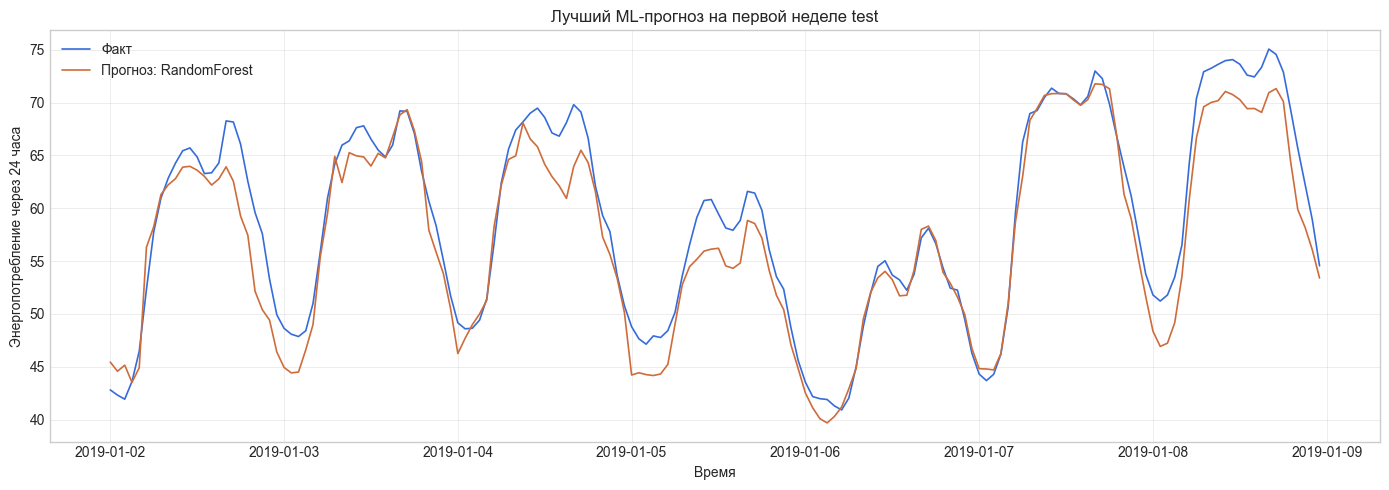

In [77]:
best_ml_model = ml_scores_df.iloc[0]["model"]
plot_n = 24 * 7

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["target_ds"].head(plot_n), y_test.head(plot_n), label="Факт", linewidth=1.2)
ax.plot(test["target_ds"].head(plot_n), ml_predictions[best_ml_model][:plot_n], label=f"Прогноз: {best_ml_model}", linewidth=1.2)
ax.set_title("Лучший ML-прогноз на первой неделе test")
ax.set_xlabel("Время")
ax.set_ylabel("Энергопотребление через 24 часа")
ax.legend()
plt.tight_layout()

## DL-модели через `neuralforecast`

DL-блок запускает три модели: `NHITS`, `NBEATS`, `LSTM`. Для выполнения этого раздела зависимости `torch` и `neuralforecast` являются обязательными.

In [78]:
nf_df = df[["ds", target_col]].rename(columns={target_col: "y"}).copy()
nf_df.insert(0, "unique_id", "DE_consumption")

nf_train_full = nf_df.loc[nf_df["ds"] < test_start].copy()
nf_test = nf_df.loc[nf_df["ds"] >= test_start].copy()
nf_train_start = pd.Timestamp(test_start) - pd.Timedelta(days=dl_train_days)
nf_train = nf_train_full.loc[nf_train_full["ds"] >= nf_train_start].copy()

print("DL train:", nf_train["ds"].min(), "->", nf_train["ds"].max(), nf_train.shape)
print("DL test:", nf_test["ds"].min(), "->", nf_test["ds"].max(), nf_test.shape)

DL train: 2017-01-01 00:00:00 -> 2018-12-31 23:00:00 (17520, 3)
DL test: 2019-01-01 00:00:00 -> 2019-12-31 23:00:00 (8760, 3)


In [ ]:
dl_trainer_config = {
    "accelerator": dl_accelerator,
    "devices": dl_devices,
}

dl_models = [
    NHITS(
        h=forecast_horizon,
        input_size=24 * 7,
        max_steps=dl_max_steps,
        random_seed=random_state,
        **dl_trainer_config,
    ),
    NBEATS(
        h=forecast_horizon,
        input_size=24 * 7,
        max_steps=dl_max_steps,
        random_seed=random_state,
        **dl_trainer_config,
    ),
    LSTM(
        h=forecast_horizon,
        input_size=24 * 7,
        max_steps=dl_max_steps,
        random_seed=random_state,
        **dl_trainer_config,
    ),
]

nf = NeuralForecast(models=dl_models, freq="h")
nf.fit(df=nf_train)
dl_forecasts = nf.predict()

dl_eval = nf_test.head(forecast_horizon).merge(dl_forecasts, on=["unique_id", "ds"], how="left")
dl_model_cols = [col for col in dl_eval.columns if col not in {"unique_id", "ds", "y"}]
if not dl_model_cols:
    raise ValueError("DL-прогноз не содержит колонок моделей")
if dl_eval[dl_model_cols].isna().any().any():
    raise ValueError("В DL-прогнозе есть пропуски после merge с test-данными")

dl_scores = [score_predictions(dl_eval["y"], dl_eval[col], col) for col in dl_model_cols]
dl_scores_df = pd.DataFrame(dl_scores).sort_values("SMAPE").reset_index(drop=True)
dl_scores_df

## Методы выявления аномалий

Использованы четыре подхода: rolling z-score по целевой переменной, Isolation Forest, One-Class SVM и LOF. Методы имеют разную логику, поэтому итоговые кандидаты в аномалии рассматриваются как точки для экспертной проверки.

In [80]:
anomaly_df = df[["ds", target_col] + weather_features].copy()
if anomaly_history_days is not None:
    anomaly_start = pd.Timestamp(test_start) - pd.Timedelta(days=anomaly_history_days)
    anomaly_df = anomaly_df.loc[anomaly_df["ds"] >= anomaly_start].copy()
anomaly_df[weather_features] = anomaly_df[weather_features].ffill().bfill()
anomaly_df["hour"] = anomaly_df["ds"].dt.hour
anomaly_df["day_of_week"] = anomaly_df["ds"].dt.dayofweek
anomaly_df["rolling_mean_24"] = anomaly_df[target_col].rolling(24, min_periods=12).mean()
anomaly_df["rolling_std_24"] = anomaly_df[target_col].rolling(24, min_periods=12).std()
anomaly_df["z_score_24"] = (anomaly_df[target_col] - anomaly_df["rolling_mean_24"]) / anomaly_df["rolling_std_24"]
anomaly_df = anomaly_df.dropna().reset_index(drop=True)

anomaly_features = [target_col, "temperature", "radiation_direct_horizontal", "radiation_diffuse_horizontal", "hour", "day_of_week"]
X_anomaly = anomaly_df[anomaly_features]

anomaly_df.head()

,ds,Consumption,temperature,radiation_direct_horizontal,radiation_diffuse_horizontal,hour,day_of_week,rolling_mean_24,rolling_std_24,z_score_24
0,2015-01-01 11:00:00,48.159,1.493,62.8690,126.2112,11,3,41.808750,3.277842,1.937326
1,2015-01-01 12:00:00,47.164,1.818,54.2607,115.7275,12,3,42.220692,3.472024,1.423754
2,2015-01-01 13:00:00,46.752,1.726,28.5704,87.5581,13,3,42.544357,3.548841,1.185639
3,2015-01-01 14:00:00,47.403,1.103,5.8398,38.3294,14,3,42.868267,3.642587,1.244921
4,2015-01-01 15:00:00,49.440,0.180,0.1808,2.2971,15,3,43.279000,3.883698,1.586375


In [81]:
anomaly_df["anomaly_zscore"] = anomaly_df["z_score_24"].abs() > 3

iso = IsolationForest(contamination=0.01, random_state=random_state, n_jobs=-1)
anomaly_df["anomaly_isolation_forest"] = iso.fit_predict(X_anomaly) == -1

lof = LocalOutlierFactor(n_neighbors=35, contamination=0.01)
anomaly_df["anomaly_lof"] = lof.fit_predict(X_anomaly) == -1

ocsvm = make_pipeline(StandardScaler(), OneClassSVM(nu=0.01, gamma="scale"))
anomaly_df["anomaly_one_class_svm"] = ocsvm.fit_predict(X_anomaly) == -1

anomaly_summary = anomaly_df[[
    "anomaly_zscore",
    "anomaly_isolation_forest",
    "anomaly_lof",
    "anomaly_one_class_svm",
]].sum().sort_values(ascending=False)

anomaly_summary

anomaly_one_class_svm       440
anomaly_isolation_forest    439
anomaly_lof                 439
anomaly_zscore               78
dtype: int64

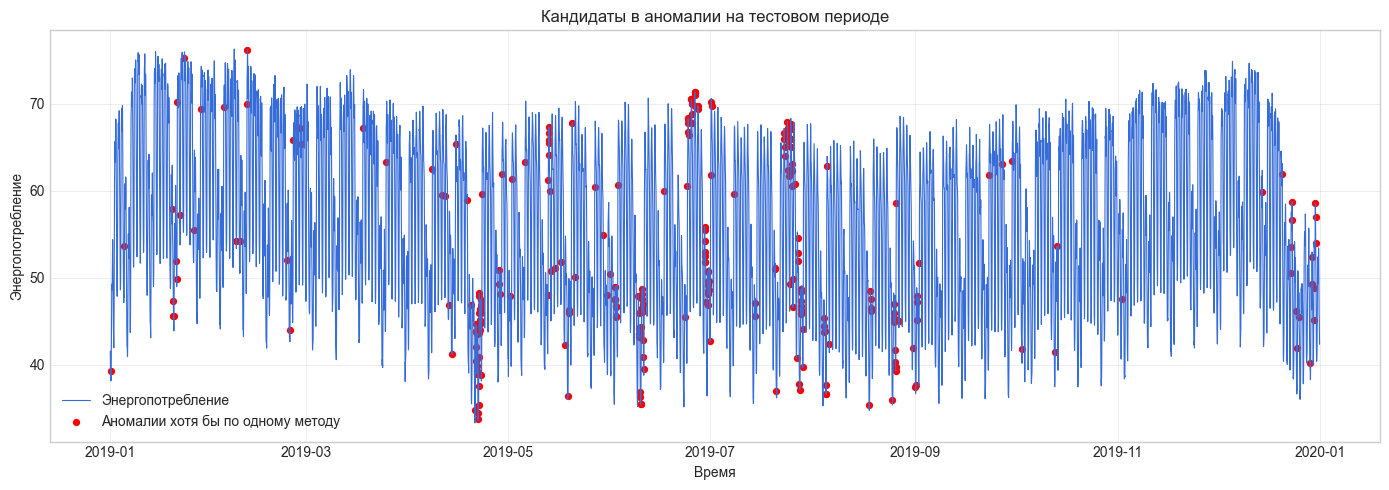

In [82]:
plot_anomalies = anomaly_df.loc[anomaly_df["ds"] >= "2019-01-01"].copy()
combined_anomaly = plot_anomalies[
    ["anomaly_zscore", "anomaly_isolation_forest", "anomaly_lof", "anomaly_one_class_svm"]
].any(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_anomalies["ds"], plot_anomalies[target_col], label="Энергопотребление", linewidth=0.8)
ax.scatter(
    plot_anomalies.loc[combined_anomaly, "ds"],
    plot_anomalies.loc[combined_anomaly, target_col],
    color="red",
    s=18,
    label="Аномалии хотя бы по одному методу",
)
ax.set_title("Кандидаты в аномалии на тестовом периоде")
ax.set_xlabel("Время")
ax.set_ylabel("Энергопотребление")
ax.legend()
plt.tight_layout()

## Итоги

In [ ]:
all_model_scores = (
    pd.concat([ml_scores_df, dl_scores_df], ignore_index=True)
    .sort_values("SMAPE")
    .reset_index(drop=True)
)

anomaly_counts_df = (
    anomaly_summary
    .rename("count")
    .reset_index()
    .rename(columns={"index": "method"})
)

summary_table = pd.DataFrame([
    {"Показатель": "QUICK_MODE", "Значение": QUICK_MODE},
    {"Показатель": "Горизонт прогноза, часов", "Значение": forecast_horizon},
    {"Показатель": "Лучшая модель по SMAPE", "Значение": all_model_scores.iloc[0]["model"]},
    {"Показатель": "DL-библиотека", "Значение": "neuralforecast"},
])

summary = {
    "quick_mode": QUICK_MODE,
    "forecast_horizon_hours": forecast_horizon,
    "best_model_by_smape": all_model_scores.iloc[0]["model"],
    "ml_scores": ml_scores_df.to_dict(orient="records"),
    "dl_scores": dl_scores_df.to_dict(orient="records"),
    "anomaly_counts": anomaly_summary.to_dict(),
}

print("Сводка запуска")
display(summary_table)
print("ML-модели, полный test-период")
display(ml_scores_df)
print("DL-модели, прямой прогноз на 24 часа")
display(dl_scores_df)
print("Общее сравнение рассчитанных моделей")
display(all_model_scores)
print("Количество кандидатов в аномалии по методам")
display(anomaly_counts_df)

В полном режиме ML-модели обучаются на полной train-истории, а DL-модели получают больше шагов обучения. GPU-режим используется для ускорения DL-блока на CUDA-совместимой видеокарте.

## Интерпретация результатов

На полном test-периоде лучшей ML-моделью стал `RandomForest`: `MAE` около 1.43, `RMSE` около 2.31 и `SMAPE` около 2.61%. Близкие результаты дали `XGBoost`, `LightGBM` и `HistGradientBoosting`, что подтверждает пользу лаговых, календарных, rolling- и погодных признаков для прогноза энергопотребления на 24 часа вперед.

Линейная модель `Ridge` заметно уступила ансамблевым моделям. Это показывает, что зависимость энергопотребления от календарных, лаговых и погодных факторов имеет нелинейный характер.

Среди DL-моделей лучший результат на прямом 24-часовом горизонте показал `NBEATS` со `SMAPE` около 3.52%. При этом итоговая финальная модель выбирается по устойчивости на полном test-периоде, поэтому для pipeline используется `RandomForest`.

Аномалии рассматриваются как кандидаты для экспертной проверки. Внешней разметки аномалий нет, поэтому в работе не утверждается точная precision/recall на реальных данных; результат используется как список подозрительных наблюдений для дальнейшего анализа.